<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia

# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from imblearn.base import BaseSampler
from sklearn.base import TransformerMixin

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV, learning_curve

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import get_scorer

from sklearn.preprocessing import FunctionTransformer, RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_recall_curve, brier_score_loss

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import average_precision_score

from feature_engine.outliers import Winsorizer

from sklearn.inspection import permutation_importance

import pickle
import shap
import sklearn

pd.set_option('display.max_columns', None)

## **0.2 Global Configuration**

In [138]:
DATA_DIR = 'Dataset' 
timestamp_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

RANDOM_STATE = 42

df = pd.read_csv(f'../{DATA_DIR}/Cleaned Data/cleaned.csv', parse_dates=timestamp_columns)
delivered = df[df["order_status"]=="delivered"]

pd.set_option('display.max_columns', None)
print(f"Dataframe size: {df.shape}")
print(f"Delivered Dataframe size: {delivered.shape}")

Dataframe size: (111777, 39)
Delivered Dataframe size: (108566, 39)


# **Section 1: Dataset Preparation**

## 1.1 splitting the data

Before we split the data we should make the target of the data beforehand

In [139]:
delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']

the dataset we have would be splitted into 3 dataset, they are train, validation, test which splitted into 60% for train and 20% both for validation and test. this data is cutoff not using randomize sample picking but using time to keep the integrity of the data being historical data.

In [140]:
order_purchase = delivered.groupby('order_id')['order_purchase_timestamp'].transform('first')
cutoff = order_purchase.quantile(0.8)
print('Test split cutoff:', cutoff)

full_train_items = delivered[order_purchase < cutoff].copy()
test_items = delivered[order_purchase >= cutoff].copy()

order_purchase = full_train_items.groupby('order_id')['order_purchase_timestamp'].transform('first')
cutoff = order_purchase.quantile(0.8)
print('Validation split cutoff:', cutoff)

validation_items = full_train_items[order_purchase >= cutoff].copy()
train_items = full_train_items[order_purchase < cutoff].copy()
print('train orders:', train_items['order_id'].nunique(), '| validation orders:', validation_items['order_id'].nunique(), '| test orders:', test_items['order_id'].nunique())

Test split cutoff: 2018-05-22 01:07:35
Validation split cutoff: 2018-03-17 11:50:35.200000
train orders: 60914 | validation orders: 15046 | test orders: 19110


## 1.2 creating lookup table based on the late delivery

In [141]:
K_SMOOTH = 10

full_train_items = full_train_items.sort_values(['seller_id', 'order_purchase_timestamp'])
full_train_items['seller_late_item'] = (
    full_train_items['shipping_limit_date'] < full_train_items['order_delivered_carrier_date']
).astype(int)

GLOBAL_LATE_RATE = full_train_items['seller_late_item'].mean()
print('global seller late-to-carrier rate (train):', round(GLOBAL_LATE_RATE, 4))

g = full_train_items.groupby('seller_id')['seller_late_item']
prior_count = g.cumcount()                                  
prior_late = g.cumsum() - full_train_items['seller_late_item'] 

full_train_items['seller_late_rate'] = (
    (prior_late + K_SMOOTH * GLOBAL_LATE_RATE) / (prior_count + K_SMOOTH)
)

first_shipment = full_train_items.groupby('seller_id').head(1)
assert np.allclose(first_shipment['seller_late_rate'], GLOBAL_LATE_RATE), 'expanding window leaked!'
print('expanding-window check passed: first shipment per seller == global rate')

global seller late-to-carrier rate (train): 0.0964
expanding-window check passed: first shipment per seller == global rate


In [142]:
seller_lookup = (
    full_train_items.groupby('seller_id')['seller_late_item']
    .agg(total_shipments='count', late_shipments='sum')
)
seller_lookup['seller_late_rate'] = (
    (seller_lookup['late_shipments'] + K_SMOOTH * GLOBAL_LATE_RATE)
    / (seller_lookup['total_shipments'] + K_SMOOTH)
)
print(seller_lookup.shape, 'sellers in lookup table')
seller_lookup.head()

(2401, 3) sellers in lookup table


,total_shipments,late_shipments,seller_late_rate
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,0,0.074123
001cca7ae9ae17fb1caed9dfb1094831,231,12,0.053791
002100f778ceb8431b7a1020ff7ab48f,54,5,0.093181
003554e2dce176b5555353e4f3555ac8,1,0,0.087599
004c9cd9d87a3c30c522c48c4fc07416,167,0,0.005444


In [143]:
def attach_seller_late_rate_frozen(items_df, lookup, global_rate):
    merged = items_df.merge(
        lookup['seller_late_rate'], on='seller_id', how='left'
    )
    merged['seller_late_rate'] = merged['seller_late_rate'].fillna(global_rate)
    return merged

example = attach_seller_late_rate_frozen(test_items, seller_lookup, GLOBAL_LATE_RATE)
n_unseen = example['seller_id'].isin(seller_lookup.index).eq(False).sum()
print(f'test rows from sellers unseen in train: {n_unseen} (fell back to global rate)')

test rows from sellers unseen in train: 2964 (fell back to global rate)


## 1.3 to make the data as valid as possible

Before we start making the pipeline for the model, what we must do is to make the data as similar as possible to the data received when there is a new order being submitted. and to do that we will only took some of the information that is needed and change the dataset into this:
| Column | Type | Description |
| --- | --- | --- |
| order_id | string | Unique identifier of the order (an order can have multiple items) |
| order_purchase_timestamp | datetime (string) | Timestamp when the order was placed. |
| product_id | string | Unique identifier of the product. |
| product_weight_g | float | Product weight in grams. |
| product_length_cm | float | Product length in cm. |
| product_height_cm | float | Product height in cm. |
| product_width_cm | float | Product width in cm. |
| seller_id | string | Unique identifier of the seller. |
| seller_zip_code_prefix | integer | First 5 digits of seller's zip code. |
| seller_geo_lat | float | Latitude of the seller zip code location. |
| seller_geo_lng | float | Longitude of the seller zip code location. |
| seller_city | string | Seller's city. |
| seller_state | string | Seller's state. |
| product_category_name_english | string | Same category translated to English. |
| customer_unique_id | string | The actual unique person (use this to track customers across multiple orders) |
| customer_zip_code_prefix | integer | First 5 digits of customer's zip code. |
| customer_geo_lat | float | Latitude of the customer zip code location. |
| customer_geo_lng | float | Longitude of the customer zip code location. |
| customer_city | string | Customer's city. |
| customer_state | string | Customer's state (Brazilian state code, e.g. SP, RJ). |
| order_estimated_delivery_date | datetime (string) | Delivery date estimate given to the customer at purchase time. |
| price | float | Item price. |
| freight_value | float | Freight/shipping cost for this item. (if an order has more than one item the freight value is splitted between items) |
| payment_sequential | integer | Sequence number if a customer used more than one payment method for the same order. |
| payment_type | string | Payment method (credit_card, boleto, voucher, debit_card). |
| n_vouchers | int | Total voucher used in that order |
| total_payment_value | float | Total payment paid for the order |
| payment_installments | integer | Number of installments chosen. |
| payment_value | float | Amount paid via this payment row. |

so basically we would erase some data that would not be usable as it is would count as a data leakage

In [144]:
DROP_COLUMNS =  ["customer_id", "order_status", "order_approved_at", "order_delivered_carrier_date", 
                 "order_delivered_customer_date", "order_item_id", "shipping_limit_date",
                 "review_score", "review_comment_message", "review_creation_date", "review_answer_timestamp"]

print('shape of train data before:', train_items.shape, ' | shape of test data before:', test_items.shape, ' | shape of validation data before:', validation_items.shape)

train_items.drop(columns=DROP_COLUMNS, inplace=True)
test_items.drop(columns=DROP_COLUMNS, inplace=True)
validation_items.drop(columns=DROP_COLUMNS, inplace=True)

print('shape of train data after:', train_items.shape, '  | shape of test data after:', test_items.shape, '  | shape of validation data after:', validation_items.shape)

shape of train data before: (69481, 40)  | shape of test data before: (21714, 40)  | shape of validation data before: (17371, 40)
shape of train data after: (69481, 29)   | shape of test data after: (21714, 29)   | shape of validation data after: (17371, 29)


## 1.4 Feature engineering

Before this dataset will be fitted into the model, we will add more features to make the model stronger. those features are these:

### 1.4.1 Volume of the product

In [145]:
feat = delivered.copy()
feat['item_volume_cm3'] = (feat['product_length_cm'] * feat['product_height_cm'] * feat['product_width_cm'])

feat.loc[:, ["order_id", "item_volume_cm3"]].head()

,order_id,item_volume_cm3
0,e481f51cbdc54678b7cc49136f2d6af7,1976.0
1,53cdb2fc8bc7dce0b6741e2150273451,4693.0
2,47770eb9100c2d0c44946d9cf07ec65d,9576.0
3,949d5b44dbf5de918fe9c16f97b45f8a,6000.0
4,ad21c59c0840e6cb83a9ceb5573f8159,11475.0


### 1.4.2 delivery distance from seller to customer in KM

In [146]:
def calculate_haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    r_earth = 6371
    return r_earth * c

In [147]:
feat["delivery_distance_km"] = calculate_haversine(feat["seller_lng"], feat["seller_lat"], feat["customer_lng"], feat["customer_lat"])
feat.loc[:, ["order_id", "delivery_distance_km"]].head()

,order_id,delivery_distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,18.576110
1,53cdb2fc8bc7dce0b6741e2150273451,851.495069
2,47770eb9100c2d0c44946d9cf07ec65d,514.410666
3,949d5b44dbf5de918fe9c16f97b45f8a,1822.226336
4,ad21c59c0840e6cb83a9ceb5573f8159,29.676625


### 1.4.3 Splitted Timestamp

In [ ]:
feat['purchase_dow'] = feat['order_purchase_timestamp'].dt.day_name()
feat['purchase_month'] = feat['order_purchase_timestamp'].dt.month_name()
feat['purchase_hour'] = feat['order_purchase_timestamp'].dt.hour
feat['promised_days'] = (feat['order_estimated_delivery_date'] - feat['order_purchase_timestamp']).dt.days

feat.loc[:, ["order_id", 'purchase_dow', "purchase_month", 'purchase_hour', 'promised_days']].head()

,order_id,purchase_dow,purchase_month,purchase_hour,promised_days
0,e481f51cbdc54678b7cc49136f2d6af7,0,10,10,15
1,53cdb2fc8bc7dce0b6741e2150273451,1,7,20,19
2,47770eb9100c2d0c44946d9cf07ec65d,2,8,8,26
3,949d5b44dbf5de918fe9c16f97b45f8a,5,11,19,26
4,ad21c59c0840e6cb83a9ceb5573f8159,1,2,21,12


### 1.4.4 black friday or holiday or not

In [217]:
def get_black_friday_date(year):
    november = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fourth_thursday = november[november.weekday == 3][3]
    return (fourth_thursday + pd.Timedelta(days=1)).normalize()

def is_black_friday_or_holiday(ts, black_friday_window_days=2):
    black_friday = get_black_friday_date(ts.year)
    is_black_friday_period = abs((ts.normalize() - black_friday).days) <= black_friday_window_days
    is_december_holiday = ts.month == 12
    return bool(is_black_friday_period or is_december_holiday)

feat['is_black_friday_or_holiday'] = feat['order_purchase_timestamp'].apply(is_black_friday_or_holiday)

feat.loc[:, ["order_id", 'is_black_friday_or_holiday']].head()

,order_id,is_black_friday_or_holiday
0,e481f51cbdc54678b7cc49136f2d6af7,False
1,53cdb2fc8bc7dce0b6741e2150273451,False
2,47770eb9100c2d0c44946d9cf07ec65d,False
3,949d5b44dbf5de918fe9c16f97b45f8a,False
4,ad21c59c0840e6cb83a9ceb5573f8159,False


### 1.4.5 dominant order

In [149]:
feat = attach_seller_late_rate_frozen(feat, seller_lookup, GLOBAL_LATE_RATE)
dominant = feat.loc[feat.groupby('order_id')['price'].idxmax()].set_index('order_id')

feat['dominant_product_category'] = feat['order_id'].map(dominant['product_category_name_english'])
feat['primary_seller_geo_state'] = feat['order_id'].map(dominant['seller_geo_state'])
feat['primary_seller_late_rate'] = feat['order_id'].map(dominant['seller_late_rate'])

feat.loc[:, ["order_id", 'dominant_product_category', "primary_seller_geo_state", 'primary_seller_late_rate']].head()

,order_id,dominant_product_category,primary_seller_geo_state,primary_seller_late_rate
0,e481f51cbdc54678b7cc49136f2d6af7,housewares,SP,0.015295
1,53cdb2fc8bc7dce0b6741e2150273451,perfumery,MG,0.026766
2,47770eb9100c2d0c44946d9cf07ec65d,auto,SP,0.040754
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,MG,0.070028
4,ad21c59c0840e6cb83a9ceb5573f8159,stationery,SP,0.038475


### 1.4.6 Information of order is interstate or intrastate

In [150]:
feat['is_interstate'] = feat['primary_seller_geo_state'] != feat['customer_geo_state']
feat['route'] = feat['primary_seller_geo_state'] + '_to_' + feat['customer_geo_state']

feat.loc[:, ["order_id", 'is_interstate', "route"]].head()

,order_id,is_interstate,route
0,e481f51cbdc54678b7cc49136f2d6af7,False,SP_to_SP
1,53cdb2fc8bc7dce0b6741e2150273451,True,MG_to_BA
2,47770eb9100c2d0c44946d9cf07ec65d,True,SP_to_GO
3,949d5b44dbf5de918fe9c16f97b45f8a,True,MG_to_RN
4,ad21c59c0840e6cb83a9ceb5573f8159,False,SP_to_SP


### 1.4.5 Aggregating Dataset

In [ ]:
out = pd.DataFrame({
    'total_price': feat.groupby('order_id')['price'].sum(),
    'total_freight_value': feat.groupby('order_id')['freight_value'].sum(),
    'total_weight_g': feat.groupby('order_id')['product_weight_g'].sum(),
    'total_volume_cm3': feat.groupby('order_id')['item_volume_cm3'].sum(),
    
    'n_items': feat.groupby('order_id').size(),
    
    'n_distinct_products': feat.groupby('order_id')['product_id'].nunique(),
    'n_distinct_categories': feat.groupby('order_id')['product_category_name_english'].nunique(),
    'n_distinct_sellers': feat.groupby('order_id')['seller_id'].nunique(),
    
    'delivery_distance_km': feat.groupby('order_id')['delivery_distance_km'].max(),
    
    'product_category': feat.groupby('order_id')['dominant_product_category'].first(),
    'seller_late_rate': feat.groupby('order_id')['primary_seller_late_rate'].first(),
    'order_purchase_timestamp': feat.groupby('order_id')['order_purchase_timestamp'].first(),
    'purchase_dow': feat.groupby('order_id')['purchase_dow'].first(),
    'purchase_month': feat.groupby('order_id')['purchase_month'].first(),
    'purchase_hour': feat.groupby('order_id')['purchase_hour'].first(),
    'promised_days': feat.groupby('order_id')['promised_days'].first(),
    'is_black_friday_or_holiday': feat.groupby('order_id')['is_black_friday_or_holiday'].first(),
    'order_estimated_delivery_date': feat.groupby('order_id')['order_estimated_delivery_date'].first(),
    'is_interstate': feat.groupby('order_id')['is_interstate'].first(),
    'route': feat.groupby('order_id')['route'].first(),
    'seller_geo_state': feat.groupby('order_id')['primary_seller_geo_state'].first(),
    'customer_geo_state': feat.groupby('order_id')['customer_geo_state'].first(),
    'payment_type': feat.groupby('order_id')['payment_type'].first(),
    'payment_installments': feat.groupby('order_id')['payment_installments'].first(),
    'total_payment_value': feat.groupby('order_id')['total_payment_value'].first(),
    'n_vouchers': feat.groupby('order_id')['n_vouchers'].first(),
    'voucher_value': feat.groupby('order_id')['voucher_value'].first(),
})

In [152]:
out.info()

<class 'pandas.DataFrame'>
Index: 95070 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   total_price                    95070 non-null  float64       
 1   total_freight_value            95070 non-null  float64       
 2   total_weight_g                 95070 non-null  float64       
 3   total_volume_cm3               95070 non-null  float64       
 4   n_items                        95070 non-null  int64         
 5   n_distinct_products            95070 non-null  int64         
 6   n_distinct_categories          95070 non-null  int64         
 7   n_distinct_sellers             95070 non-null  int64         
 8   delivery_distance_km           95070 non-null  float64       
 9   product_category               93722 non-null  str           
 10  seller_late_rate               95070 non

## 1.5 Pipeline

### 1.5.3 Feature Fixing

In [ ]:
def aggregate_order_features(items_df):
    feat = items_df.copy()
    feat = attach_seller_late_rate_frozen(feat, seller_lookup, GLOBAL_LATE_RATE)
    feat['item_volume_cm3'] = (
        feat['product_length_cm'] * feat['product_height_cm'] * feat['product_width_cm']
    )
    feat['seller_customer_distance_km'] = calculate_haversine(
        feat['seller_lat'], feat['seller_lng'], feat['customer_lat'], feat['customer_lng']
    )

    feat['purchase_dow'] = feat['order_purchase_timestamp'].dt.day_name()
    feat['purchase_month'] = feat['order_purchase_timestamp'].dt.month_name()
    feat['purchase_hour'] = feat['order_purchase_timestamp'].dt.hour
    feat['promised_days'] = (feat['order_estimated_delivery_date'] - feat['order_purchase_timestamp']).dt.days
    feat['is_black_friday_or_holiday'] = feat['order_purchase_timestamp'].apply(is_black_friday_or_holiday)
    
    dominant = feat.loc[feat.groupby('order_id')['price'].idxmax()].set_index('order_id')

    out = pd.DataFrame({
        'total_price': feat.groupby('order_id')['price'].sum(),
        'total_freight_value': feat.groupby('order_id')['freight_value'].sum(),
        'total_weight_g': feat.groupby('order_id')['product_weight_g'].sum(),
        'total_volume_cm3': feat.groupby('order_id')['item_volume_cm3'].sum(),
        
        'n_items': feat.groupby('order_id').size(),
        
        'n_distinct_products': feat.groupby('order_id')['product_id'].nunique(),
        'n_distinct_categories': feat.groupby('order_id')['product_category_name_english'].nunique(),
        'n_distinct_sellers': feat.groupby('order_id')['seller_id'].nunique(),
        
        'delivery_distance_km': feat.groupby('order_id')['seller_customer_distance_km'].max(),
        
        'order_purchase_timestamp': feat.groupby('order_id')['order_purchase_timestamp'].first(),
        'order_estimated_delivery_date': feat.groupby('order_id')['order_estimated_delivery_date'].first(),
        'purchase_dow': feat.groupby('order_id')['purchase_dow'].first(),
        'purchase_month': feat.groupby('order_id')['purchase_month'].first(),
        'purchase_hour': feat.groupby('order_id')['purchase_hour'].first(),
        'promised_days': feat.groupby('order_id')['promised_days'].first(),
        'is_black_friday_or_holiday': feat.groupby('order_id')['is_black_friday_or_holiday'].first(),
        'customer_geo_state': feat.groupby('order_id')['customer_geo_state'].first(),
        'payment_type': feat.groupby('order_id')['payment_type'].first(),
        'payment_installments': feat.groupby('order_id')['payment_installments'].first(),
        'total_payment_value': feat.groupby('order_id')['total_payment_value'].first(),
        'n_vouchers': feat.groupby('order_id')['n_vouchers'].first(),
        'voucher_value': feat.groupby('order_id')['voucher_value'].first(),
    })

    if 'is_late' in feat.columns:
        out['is_late'] = feat.groupby('order_id')['is_late'].first().astype(int)

    out['dominant_product_category'] = dominant['product_category_name_english'].reindex(out.index)
    out['primary_seller_geo_state'] = dominant['seller_geo_state'].reindex(out.index)
    out['primary_seller_late_rate'] = dominant['seller_late_rate'].reindex(out.index)

    
    
    out['is_interstate'] = out['primary_seller_geo_state'] != out['customer_geo_state']
    out['route'] = out['primary_seller_geo_state'] + '_to_' + out['customer_geo_state']

    return out


In [154]:
pipeline_engineer_step = FunctionTransformer(aggregate_order_features)


### 1.5.1 Feature & Target

In [155]:
def split_xy(df):
    agg = aggregate_order_features(df)
    y = agg.pop("is_late")
    X = agg
    return X, y

X_train, y_train = split_xy(train_items)
X_val, y_val = split_xy(validation_items)
X_test, y_test = split_xy(test_items)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

X_train: (60914, 26) | y_train: (60914,)
X_val:   (15046, 26) | y_val:   (15046,)
X_test:  (19110, 26) | y_test:  (19110,)


In [204]:
_train_order = X_train['order_purchase_timestamp'].sort_values().index
X_train = X_train.loc[_train_order]
y_train = y_train.loc[_train_order]

print("X_train sorted chronologically:", X_train['order_purchase_timestamp'].is_monotonic_increasing)

X_train sorted chronologically: True


### 1.5.3 Imputing & Encoding

In [187]:
X_train.nunique()

total_price                       5547
total_freight_value               5994
total_weight_g                    2251
total_volume_cm3                  4797
n_items                             16
n_distinct_products                  7
n_distinct_categories                4
n_distinct_sellers                   5
delivery_distance_km             57840
order_purchase_timestamp         60585
order_estimated_delivery_date      341
customer_geo_state                  27
payment_type                         4
payment_installments                22
total_payment_value              19272
n_vouchers                          19
voucher_value                     1823
dominant_product_category           70
primary_seller_geo_state            21
primary_seller_late_rate           643
purchase_dow                         7
purchase_month                      12
purchase_hour                       24
promised_days                       94
is_interstate                        2
route                    

now what we needed to do is to split the data into types of data it is. and to be fair the impute will only be done into some data that needed it. in this case are the data in which handled by seller for example: `total_weight_g`, `total_volume_cm3` and `product_category`. the other data would not be imputed as it is something that have to be filled and also filled by system. so it would be considered as not possible to be missing except for system fatal error.

In [207]:
DROP_FOR_MODEL = [
    'order_purchase_timestamp', 'order_estimated_delivery_date'
]

numeric_features = [
    'total_price', 'total_freight_value','n_items', 'n_distinct_products', 
    'n_distinct_categories', 'n_distinct_sellers', 'delivery_distance_km', 
    'primary_seller_late_rate', 'purchase_dow', 'purchase_month', 'purchase_hour', 
    'promised_days', 'payment_installments', 'total_payment_value',
    'n_vouchers', 'voucher_value',
]

oh_categorical_features = [
    'payment_type'
]

bin_categorical_features = [
    'route', 'primary_seller_geo_state', 'customer_geo_state', 'payment_type',
]

imputed_numeric_features = [
    'total_weight_g', 'total_volume_cm3'
]

imputed_categorical_features = ['dominant_product_category']

boolean_features = ['is_interstate']

In [208]:
def convert_bool_to_int(df):
    return df.astype(int)

imputed_numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', RobustScaler()),
])

imputed_categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encode', BinaryEncoder(handle_unknown='value')),
])

numeric_pipeline = Pipeline([
    ('scale', RobustScaler()),
])

oh_categorical_pipeline = Pipeline([
    ('encode', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False)),
])

bin_categorical_pipeline = Pipeline([
    ('encode', BinaryEncoder(handle_unknown='value')),
])

boolean_pipeline = Pipeline([
    ('transform', FunctionTransformer(convert_bool_to_int, validate=False))
])

preprocessor = ColumnTransformer([
    ('im_num', imputed_numeric_pipeline, imputed_numeric_features),
    ('im_cat', imputed_categorical_pipeline, imputed_categorical_features),
    ('num', numeric_pipeline, numeric_features),
    ('oh_cat', oh_categorical_pipeline, oh_categorical_features),
    ('bin_cat', bin_categorical_pipeline, bin_categorical_features),
    ('bool', boolean_pipeline, boolean_features),
], remainder='drop')

### 1.5.4 Full Pipeline

In [209]:
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('select', 'passthrough'),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

pipeline

,steps,"[('preprocessor', ...), ('select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('im_num', ...), ('im_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for for

# **Section 2: Model Benchmarking**

In [215]:
def benchmark_models(pipeline, list_model, x_train, y_train, 
                     scoring="roc_auc", cv=5, random_state=None, select="passthrough"):

    all_cv_result = []

    tscv = TimeSeriesSplit(n_splits=cv)

    metric_names = [scoring] if isinstance(scoring, str) else list(scoring)

    for name, model in list_model.items():
        classifier = pipeline.set_params(classifier=model, select=select)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=tscv,
            scoring=scoring,
            return_train_score=True
        )

        row = {"name": name}
        for metric in metric_names:
            result_key = "score" if isinstance(scoring, str) else metric
            row[f"mean_train_{metric}"] = np.mean(cv_result[f"train_{result_key}"])
            row[f"std_train_{metric}"] = np.std(cv_result[f"train_{result_key}"])
            row[f"mean_test_{metric}"] = np.mean(cv_result[f"test_{result_key}"])
            row[f"std_test_{metric}"] = np.std(cv_result[f"test_{result_key}"])
        all_cv_result.append(row)

    sort_col = f"mean_test_{metric_names[0]}"
    result_df = pd.DataFrame(all_cv_result).sort_values(
        sort_col, ascending=False
    ).reset_index(drop=True)

    return result_df

In [ ]:
list_linear_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Ridge Classifier": RidgeClassifier(random_state=RANDOM_STATE),
    "Linear SVM (LinearSVC)": LinearSVC(dual="auto", max_iter=5000, random_state=RANDOM_STATE),
    "Linear SVM (SVC Linear)": SVC(kernel="linear", random_state=RANDOM_STATE),
    "SGD Classifier": SGDClassifier(random_state=RANDOM_STATE),
    "Bagged Logistic Regression": BaggingClassifier(
        estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    )
}

linear_select = SelectKBest(f_classif, k=20)

linear_benchmark_selected = benchmark_models(
    pipeline=pipeline,
    list_model=list_linear_models,
    x_train=X_train, y_train=y_train,
    cv=5, random_state=RANDOM_STATE,
    scoring="average_precision",
    select=linear_select,
)

display(linear_benchmark_selected)

c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,name,mean_train_average_precision,std_train_average_precision,mean_test_average_precision,std_test_average_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall
0,Logistic Regression,0.217412,0.001406,0.213189,0.003195,0.645283,0.004783,0.636326,0.013955
1,Bagged Logistic Regression,0.217295,0.001474,0.213167,0.003060,0.645791,0.004739,0.638726,0.014521
2,Linear SVM (LinearSVC),0.217406,0.001465,0.213125,0.003251,0.642606,0.006068,0.634481,0.012339
3,Ridge Classifier,0.215864,0.001558,0.211555,0.003074,0.643345,0.005324,0.630790,0.010187
4,Linear SVM (SVC Linear),0.210070,0.001763,0.206095,0.002575,0.630099,0.006592,0.618609,0.010493
5,SGD Classifier,0.196418,0.010446,0.193149,0.014435,0.642421,0.035862,0.635593,0.025136


In [216]:
list_tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting (GBM)": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
}

tree_benchmark_selected = benchmark_models(
    pipeline=pipeline,
    list_model=list_tree_models,
    x_train=X_train, y_train=y_train,
    cv=5, random_state=RANDOM_STATE,
    scoring="average_precision"
)

display(tree_benchmark_selected)

,name,mean_train_average_precision,std_train_average_precision,mean_test_average_precision,std_test_average_precision
0,LightGBM,0.511591,1.997823e-01,0.171236,0.111252
1,XGBoost,0.794530,1.579965e-01,0.158593,0.103190
2,Gradient Boosting (GBM),0.156757,4.008529e-02,0.145602,0.099198
3,AdaBoost,0.103678,4.117633e-02,0.142278,0.097542
4,Random Forest,1.000000,4.193657e-07,0.141939,0.088710
5,Extra Trees,1.000000,2.065149e-07,0.133759,0.080956
6,Decision Tree,1.000000,2.065149e-07,0.100010,0.062989


# Section 3: Parameter Tuning

In [ ]:
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500, 800],
    'classifier__learning_rate': [0.01, 0.02, 0.05, 0.1],
    'classifier__num_leaves': [15, 31, 63, 127],
    'classifier__max_depth': [-1, 4, 6, 8, 10],
    'classifier__min_child_samples': [10, 20, 30, 50],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 0.5, 1.0],
    'classifier__reg_lambda': [0, 0.1, 0.5, 1.0],
}

tuning_pipeline = pipeline.set_params(
    classifier=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, class_weight='balanced'),
    smote='passthrough',
)


search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='average_precision',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Best CV average_precision:", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV average_precision: 0.3148784439067794
Best params: {'classifier__subsample': 1.0, 'classifier__reg_lambda': 0, 'classifier__reg_alpha': 0, 'classifier__num_leaves': 15, 'classifier__n_estimators': 800, 'classifier__min_child_samples': 30, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.6}


In [198]:
best_pipeline = search.best_estimator_

val_proba_uncalibrated = best_pipeline.predict_proba(X_val)[:, 1]
print("Validation average_precision (uncalibrated):",
      average_precision_score(y_val, val_proba_uncalibrated))

Validation average_precision (uncalibrated): 0.22397120504857915


# Section 4: Proba Calibration

In [199]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_pipeline),
    method='isotonic'
)
calibrated_pipeline.fit(X_val, y_val)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...erbose=-1))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the c

Test average_precision - uncalibrated: 0.11959672436928112
Test average_precision - calibrated:   0.11188330778409318

Test Brier score - uncalibrated: 0.049759838546880646
Test Brier score - calibrated:   0.04958576651760047


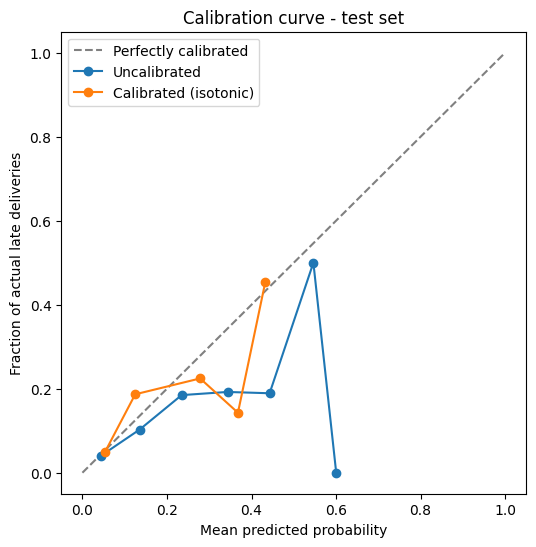

In [200]:
proba_uncalibrated = best_pipeline.predict_proba(X_test)[:, 1]
proba_calibrated = calibrated_pipeline.predict_proba(X_test)[:, 1]

print("Test average_precision - uncalibrated:", average_precision_score(y_test, proba_uncalibrated))
print("Test average_precision - calibrated:  ", average_precision_score(y_test, proba_calibrated))
print()
print("Test Brier score - uncalibrated:", brier_score_loss(y_test, proba_uncalibrated))
print("Test Brier score - calibrated:  ", brier_score_loss(y_test, proba_calibrated))
# average_precision is rank-based, so isotonic calibration (monotonic) should
# leave it roughly unchanged - it's the Brier score / calibration curve below
# that should visibly improve if calibration helped.

frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, proba_uncalibrated, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_calibrated, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.plot(mean_pred_uncal, frac_pos_uncal, marker='o', label='Uncalibrated')
plt.plot(mean_pred_cal, frac_pos_cal, marker='o', label='Calibrated (isotonic)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual late deliveries')
plt.title('Calibration curve - test set')
plt.legend()
plt.show()

# Section 5: Risk Tier

In [201]:
risk_table = pd.DataFrame({
    "y_true": y_test.values,
    "proba": proba_calibrated,
})

risk_table["risk_tier"], tier_edges = pd.qcut(
    risk_table["proba"], q=[0, 0.7, 0.9, 1.0], labels=["Low", "Medium", "High"],
    retbins=True
)

tier_summary = risk_table.groupby("risk_tier").agg(
    n_orders=("y_true", "size"),
    actual_late_rate=("y_true", "mean"),
    avg_predicted_proba=("proba", "mean"),
)

print("Low  | proba <", round(tier_edges[1], 4))
print("Med  |", round(tier_edges[1], 4), "<= proba <", round(tier_edges[2], 4))
print("High | proba >=", round(tier_edges[2], 4))
print()

tier_summary

Low  | proba < 0.0716
Med  | 0.0716 <= proba < 0.0927
High | proba >= 0.0927



,n_orders,actual_late_rate,avg_predicted_proba
risk_tier,,,
Low,15612,0.040033,0.047841
Medium,2648,0.098187,0.081547
High,850,0.168235,0.134084


In [202]:
top_pct_options = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]

n_total = len(risk_table)
n_late_total = risk_table["y_true"].sum()
sorted_risk = risk_table.sort_values("proba", ascending=False).reset_index(drop=True)

rows = []
for pct in top_pct_options:
    n_flagged = int(np.ceil(n_total * pct))
    flagged = sorted_risk.iloc[:n_flagged]
    n_correct = flagged["y_true"].sum()
    precision = n_correct / n_flagged
    recall = n_correct / n_late_total
    rows.append({
        "top_pct_flagged": f"{pct:.0%}",
        "n_notifications": n_flagged,
        "precision_pct_correct": round(precision * 100, 1),
        "false_alarm_pct": round((1 - precision) * 100, 1),
        "recall_pct_late_caught": round(recall * 100, 1),
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,top_pct_flagged,n_notifications,precision_pct_correct,false_alarm_pct,recall_pct_late_caught
0,2%,383,21.4,78.6,8.0
1,5%,956,16.2,83.8,15.1
2,8%,1529,14.5,85.5,21.5
3,10%,1911,13.9,86.1,25.9
4,15%,2867,12.2,87.8,34.0
5,20%,3822,11.1,88.9,41.1
6,30%,5733,9.4,90.6,52.5
7,50%,9555,8.3,91.7,76.8


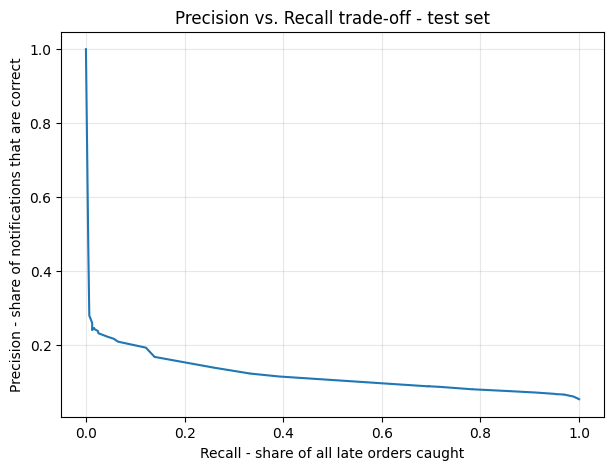

In [203]:
precisions, recalls, pr_thresholds = precision_recall_curve(risk_table["y_true"], risk_table["proba"])

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall - share of all late orders caught")
plt.ylabel("Precision - share of notifications that are correct")
plt.title("Precision vs. Recall trade-off - test set")
plt.grid(alpha=0.3)
plt.show()